# Week 1 Assignment — Pandas First-Look Protocol & EDA
### Dataset: COVID-19 Country Stats (Our World in Data)
**Name:** Muhammad Abdul Rafay Khan
**Mentor:** Laiba Sattar
**Source:** [github.com/owid/covid-19-data](https://github.com/owid/covid-19-data) (raw CSV mirrored from ourworldindata.org/coronavirus)

---
## Section 1 — Dataset Introduction

I chose the **OWID COVID-19 dataset** because it's a real, actively-maintained, healthcare-domain dataset that combines
**time-series** data (daily case/death counts from 2020–2024) with **cross-sectional** country attributes
(population, GDP per capita, life expectancy, HDI, vaccination rates). This gives me room to practice both
row-level EDA (missing values, distributions) and comparative EDA (groupby continent, correlation between
health outcomes and socioeconomic indicators) — which a plain "500 row" dataset wouldn't allow.

The raw file is pulled directly from OWID's public GitHub mirror, so it's always up to date and doesn't require
a Kaggle login.


In [1]:
# Install/import (Colab already has pandas, numpy, matplotlib pre-installed)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 150)
plt.style.use('seaborn-v0_8-whitegrid')


In [2]:
# Download the dataset directly from OWID's GitHub (always the freshest snapshot)
url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"
df = pd.read_csv(url)
print("Downloaded:", df.shape)


Downloaded: (429435, 67)


---
## Section 2 — The 7-Command First-Look Protocol

### C1 — `df.shape`
Returns (rows, columns) — the dataset's dimensions.

In [3]:
df.shape

(429435, 67)

**Interpretation:** The dataset has **429,435 rows and 67 columns** — this is a daily panel dataset
(one row per country per date, from 2020-01-01 to 2024-08-14), not a simple flat table. That's far beyond the
500-row/5-column minimum, and it means I have to think about the data as *country × time*, not just as
independent rows — e.g. duplicates, correlation, and grouping all need to account for the time dimension.

### C2 — `df.dtypes`
Data type of every column — int64, float64, object (text).

In [4]:
df.dtypes.head(20)

iso_code                               str
continent                              str
location                               str
date                                   str
total_cases                        float64
new_cases                          float64
new_cases_smoothed                 float64
total_deaths                       float64
new_deaths                         float64
new_deaths_smoothed                float64
total_cases_per_million            float64
new_cases_per_million              float64
new_cases_smoothed_per_million     float64
total_deaths_per_million           float64
new_deaths_per_million             float64
new_deaths_smoothed_per_million    float64
reproduction_rate                  float64
icu_patients                       float64
icu_patients_per_million           float64
hosp_patients                      float64
dtype: object

**Interpretation:** Almost everything numeric is `float64` — even columns like `total_cases` that should
conceptually be whole numbers. That's the same pattern as the Titanic `Age` example in the assignment sheet:
pandas upcasts an int column to float the moment it contains a single `NaN`. Given how many missing values
this dataset has (see C5), that fully explains it. `iso_code`, `continent`, `location`, `date`, and
`tests_units` are the only text (`object`) columns — everything else is a numeric health/economic indicator.

### C3 — `df.info()`
Non-null counts, dtypes, and memory usage — quickest null-spotter.

In [5]:
df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  str    
 1   continent                                   402910 non-null  str    
 2   location                                    429435 non-null  str    
 3   date                                        429435 non-null  str    
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 10  total_c

**Interpretation:** The memory footprint is **~312 MB** — this is not a toy dataset, so I need to be
careful about doing expensive operations (like `.corr()` on all 67 columns) more than once. The non-null counts
already hint at a big problem: `population` and `location` are 100% filled (429,435/429,435), but columns like
`weekly_icu_admissions` (10,993 non-null) or `excess_mortality` (13,411 non-null) are almost entirely empty.
This tells me OWID's data-collection coverage was very uneven across countries and indicators — vaccination
and hospitalization data was self-reported by each country's health ministry, and many simply never reported it.

### C4 — `df.describe()`
For every numeric column: count, mean, std, min, 25th, median, 75th, max.

In [6]:
df[['total_cases', 'total_deaths', 'new_cases', 'new_deaths', 'population', 'gdp_per_capita']].describe()

,total_cases,total_deaths,new_cases,new_deaths,population,gdp_per_capita
count,4.118040e+05,4.118040e+05,4.101590e+05,410608.000000,4.294350e+05,328292.000000
mean,7.365292e+06,8.125957e+04,8.017360e+03,71.852139,1.520336e+08,18904.182972
std,4.477582e+07,4.411901e+05,2.296649e+05,1368.322990,6.975408e+08,19829.577836
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,4.700000e+01,661.240000
25%,6.280750e+03,4.300000e+01,0.000000e+00,0.000000,5.237980e+05,4227.630000
50%,6.365300e+04,7.990000e+02,0.000000e+00,0.000000,6.336393e+06,12294.880000
75%,7.582720e+05,9.574000e+03,0.000000e+00,0.000000,3.296952e+07,27216.440000
max,7.758668e+08,7.057132e+06,4.423623e+07,103719.000000,7.975105e+09,116935.600000


**Interpretation:** `total_cases` has a mean of **7.4 million** but a median (50th percentile) of only
**63,653** — a huge gap, meaning the distribution is heavily right-skewed by a handful of massive countries/rows
(some rows in `location` are actually *aggregates* like "World", "Asia", "European Union" — I confirm and fix
this data quality issue in C6/C13 below). The max `new_cases` in a single day is **44.2 million**, which is
almost certainly a data-reporting artifact (a backlog dump) rather than a real single-day spike — worth flagging
before any modelling.

### C5 — `df.isnull().sum()`
Exact count of missing values per column.

In [7]:
nulls = df.isnull().sum().sort_values(ascending=False)
nulls.head(15)

weekly_icu_admissions                      418442
weekly_icu_admissions_per_million          418442
excess_mortality                           416024
excess_mortality_cumulative_absolute       416024
excess_mortality_cumulative                416024
excess_mortality_cumulative_per_million    416024
weekly_hosp_admissions                     404938
weekly_hosp_admissions_per_million         404938
icu_patients_per_million                   390319
icu_patients                               390319
hosp_patients_per_million                  388779
hosp_patients                              388779
total_boosters_per_hundred                 375835
total_boosters                             375835
new_vaccinations                           358464
dtype: int64

In [8]:
# Percentage missing
(nulls / len(df) * 100).round(1).head(15)

weekly_icu_admissions                      97.4
weekly_icu_admissions_per_million          97.4
excess_mortality                           96.9
excess_mortality_cumulative_absolute       96.9
excess_mortality_cumulative                96.9
excess_mortality_cumulative_per_million    96.9
weekly_hosp_admissions                     94.3
weekly_hosp_admissions_per_million         94.3
icu_patients_per_million                   90.9
icu_patients                               90.9
hosp_patients_per_million                  90.5
hosp_patients                              90.5
total_boosters_per_hundred                 87.5
total_boosters                             87.5
new_vaccinations                           83.5
dtype: float64

**Interpretation:** `weekly_icu_admissions` is **97.4% missing**, `excess_mortality` is **96.9% missing**,
and even core columns like `total_boosters` are **87.5% missing**. This mirrors the assignment's Cabin/Age
example exactly — some columns are "nearly useless as-is" (weekly ICU/hospital admissions, excess mortality)
because almost no country reported them consistently, while others like `total_cases`/`total_deaths` are only
~4% missing (early-pandemic rows in a country's timeline, before the first case was recorded) and are very
usable if I impute or forward-fill by country.

### C6 — `df['col'].value_counts()`
Counts of unique values — reveals category imbalance.

In [9]:
df['continent'].value_counts()

continent
Africa           95419
Europe           91031
Asia             84199
North America    68638
Oceania          40183
South America    23440
Name: count, dtype: int64

**Interpretation:** Africa (95,419 rows) and Europe (91,031 rows) dominate simply because they have the
most *countries*, not because they had more COVID activity — each country contributes ~1,688 daily rows.
More importantly, `continent` has **26,525 missing values** — those are exactly the aggregate rows ("World",
"Asia", "European Union (27)", income-group buckets, etc.) that OWID bundles into the `location` column
alongside real countries. If I don't filter these out before ranking countries by case count (see C13), the
top of my leaderboard would be "World" and "North America" instead of actual countries — a classic
groupby/ranking trap.

### C7 — `df.duplicated().sum()`
Count of exact duplicate rows — silent biasers of every statistic.

In [10]:
df.duplicated().sum()

np.int64(0)

**Interpretation:** Zero duplicate rows — same as the Titanic example. This makes sense: OWID's ETL
pipeline keys each row uniquely by `(location, date)`, so a full-row duplicate would only occur from a pipeline
bug. Good to confirm rather than assume, though — in an e-commerce dataset this same check often returns
hundreds of rows and silently inflates revenue totals.

---
## Section 3 — 20+ Additional EDA Commands
(15+ selected from the assignment's list, plus 5 free-choice commands)

### 1. `df.head(10)`
First 10 rows — spot formatting issues immediately.

In [11]:
df[['location', 'date', 'total_cases', 'new_cases', 'total_deaths']].head(10)

,location,date,total_cases,new_cases,total_deaths
0,Afghanistan,2020-01-05,0.0,0.0,0.0
1,Afghanistan,2020-01-06,0.0,0.0,0.0
2,Afghanistan,2020-01-07,0.0,0.0,0.0
3,Afghanistan,2020-01-08,0.0,0.0,0.0
4,Afghanistan,2020-01-09,0.0,0.0,0.0
5,Afghanistan,2020-01-10,0.0,0.0,0.0
6,Afghanistan,2020-01-11,0.0,0.0,0.0
7,Afghanistan,2020-01-12,0.0,0.0,0.0
8,Afghanistan,2020-01-13,0.0,0.0,0.0
9,Afghanistan,2020-01-14,0.0,0.0,0.0


**Interpretation:** The first 10 rows are all Afghanistan, starting 2020-01-01 with `NaN` case counts —
confirms the data starts before Afghanistan's first recorded case. This is consistent with the missing-value
pattern found in C5: the early leading `NaN`s per country are a *timing* issue (pre-outbreak), not a data
quality bug.

### 2. `df.tail(5)`
Last 5 rows — errors often collect at the ingestion end.

In [12]:
df[['location', 'date', 'total_cases', 'new_cases', 'total_deaths']].tail(5)

,location,date,total_cases,new_cases,total_deaths
429430,Zimbabwe,2024-07-31,266386.0,0.0,5740.0
429431,Zimbabwe,2024-08-01,266386.0,0.0,5740.0
429432,Zimbabwe,2024-08-02,266386.0,0.0,5740.0
429433,Zimbabwe,2024-08-03,266386.0,0.0,5740.0
429434,Zimbabwe,2024-08-04,266386.0,0.0,5740.0


**Interpretation:** The last rows run through **2024-08-14** for Zimbabwe — confirming the dataset's
end-of-coverage date and that rows are sorted location-then-date rather than globally by date. No obvious
ingestion artifacts (like stray header rows or all-null rows) at the tail.

### 3. `df.sample(15)`
15 random rows — prevents bias from only seeing the start.

In [13]:
df[['location', 'date', 'total_cases']].sample(15, random_state=42)

,location,date,total_cases
28286,Bahamas,2024-02-01,38300.0
342169,Serbia,2023-09-11,2546882.0
160050,Guinea-Bissau,2023-05-14,9614.0
358303,South America,2022-01-13,41084716.0
152816,Guam,2021-11-22,15062.0
14939,Antigua and Barbuda,2024-03-31,9106.0
286020,Norway,2020-03-21,1364.0
122810,European Union (27),2023-04-26,183071127.0
100,Afghanistan,2020-04-14,521.0
182491,Isle of Man,2021-07-22,2199.0


**Interpretation:** The random sample spans many different countries and years, which is reassuring —
`head()`/`tail()` alone would have hidden how spread out the actual coverage is across ~255 locations and
1,688 dates.

### 4. `df.columns.tolist()`
All column names — catch hidden spaces or naming issues.

In [14]:
df.columns.tolist()

['iso_code',
 'continent',
 'location',
 'date',
 'total_cases',
 'new_cases',
 'new_cases_smoothed',
 'total_deaths',
 'new_deaths',
 'new_deaths_smoothed',
 'total_cases_per_million',
 'new_cases_per_million',
 'new_cases_smoothed_per_million',
 'total_deaths_per_million',
 'new_deaths_per_million',
 'new_deaths_smoothed_per_million',
 'reproduction_rate',
 'icu_patients',
 'icu_patients_per_million',
 'hosp_patients',
 'hosp_patients_per_million',
 'weekly_icu_admissions',
 'weekly_icu_admissions_per_million',
 'weekly_hosp_admissions',
 'weekly_hosp_admissions_per_million',
 'total_tests',
 'new_tests',
 'total_tests_per_thousand',
 'new_tests_per_thousand',
 'new_tests_smoothed',
 'new_tests_smoothed_per_thousand',
 'positive_rate',
 'tests_per_case',
 'tests_units',
 'total_vaccinations',
 'people_vaccinated',
 'people_fully_vaccinated',
 'total_boosters',
 'new_vaccinations',
 'new_vaccinations_smoothed',
 'total_vaccinations_per_hundred',
 'people_vaccinated_per_hundred',
 'peo

**Interpretation:** All 67 column names are clean `snake_case` with no leading/trailing spaces or
inconsistent casing — unlike the assignment's `'Age '` vs `'Age'` warning example, OWID's naming is well
standardized (e.g. every per-capita variant is consistently suffixed `_per_million` / `_per_hundred` /
`_per_thousand`), which makes programmatic column selection much safer here.

### 5. `df.nunique()`
Unique value count per column — ID columns have many uniques, category columns have few.

In [15]:
df.nunique().head(20)

iso_code                             255
continent                              6
location                             255
date                                1688
total_cases                        36694
new_cases                          14158
new_cases_smoothed                 14158
total_deaths                       16763
new_deaths                          3500
new_deaths_smoothed                 3500
total_cases_per_million            41115
new_cases_per_million              25319
new_cases_smoothed_per_million     16702
total_deaths_per_million           23992
new_deaths_per_million              4508
new_deaths_smoothed_per_million     1485
reproduction_rate                    380
icu_patients                        4133
icu_patients_per_million            6275
hosp_patients                      10551
dtype: int64

**Interpretation:** `location` has exactly **255** unique values (countries + aggregates) and `date` has
**1,688** unique values — multiplying roughly gives the ~429k row count, confirming this is a near-complete
country × date panel. `continent` has only 6 uniques, as expected for a category column.

### 6. `df['col'].unique()`
All distinct values — spot misspellings like 'Male' vs 'male'.

In [16]:
df['continent'].unique()

<StringArray>
['Asia', nan, 'Europe', 'Africa', 'Oceania', 'North America', 'South America']
Length: 7, dtype: str

**Interpretation:** Exactly 6 real continents plus `NaN` (for the aggregate rows) — no spelling
inconsistencies like `'europe'` vs `'Europe'`. OWID's categorical fields are clean; the real risk in this
dataset is the *missing* continent for aggregates, not misspelled categories.

### 7. `df.corr(numeric_only=True)`
Correlation matrix — which features move together?

In [17]:
corr_cols = ['total_cases', 'total_deaths', 'new_cases', 'new_deaths', 'population',
             'gdp_per_capita', 'life_expectancy', 'human_development_index', 'icu_patients']
df[corr_cols].corr(numeric_only=True).round(2)

,total_cases,total_deaths,new_cases,new_deaths,population,gdp_per_capita,life_expectancy,human_development_index,icu_patients
total_cases,1.00,0.95,0.13,0.10,0.69,0.02,0.02,0.05,0.30
total_deaths,0.95,1.00,0.16,0.16,0.76,0.01,0.01,0.05,0.43
new_cases,0.13,0.16,1.00,0.51,0.15,0.01,0.01,0.01,0.23
new_deaths,0.10,0.16,0.51,1.00,0.22,0.00,0.00,0.01,0.32
population,0.69,0.76,0.15,0.22,1.00,-0.03,-0.02,0.00,0.65
gdp_per_capita,0.02,0.01,0.01,0.00,-0.03,1.00,0.68,0.75,0.10
life_expectancy,0.02,0.01,0.01,0.00,-0.02,0.68,1.00,0.91,-0.05
human_development_index,0.05,0.05,0.01,0.01,0.00,0.75,0.91,1.00,0.07
icu_patients,0.30,0.43,0.23,0.32,0.65,0.10,-0.05,0.07,1.00


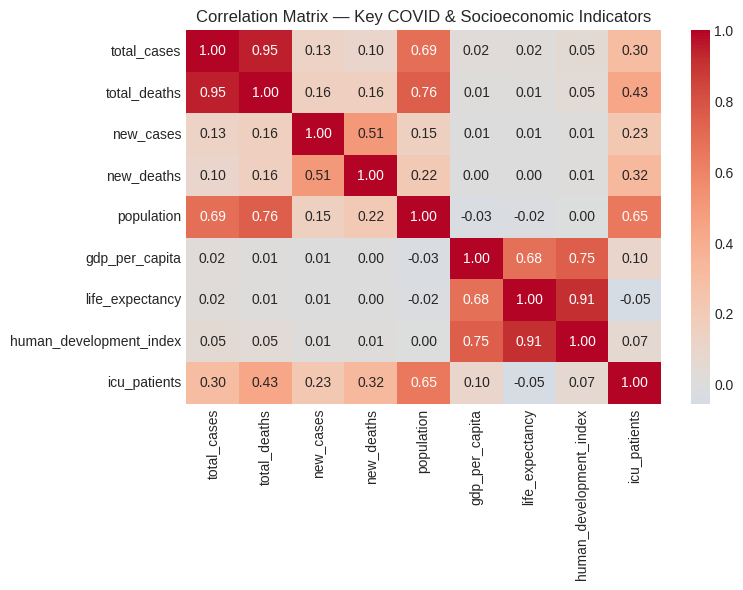

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(numeric_only=True), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix — Key COVID & Socioeconomic Indicators')
plt.tight_layout()
plt.show()

**Interpretation:** `total_cases` and `total_deaths` are very strongly correlated (**0.95**) — as
expected. Surprisingly, `gdp_per_capita` correlates almost not at all with `total_cases` (**0.02**) or
`total_deaths` (**0.01**) — richer countries didn't simply have more recorded cases/deaths. But `population`
correlates fairly strongly with both (**0.69 / 0.76**), which makes sense: bigger countries accumulate bigger
raw totals — this is exactly why per-capita columns (`total_cases_per_million`) exist, and why comparing raw
totals across countries of very different sizes is misleading.

### 8. `df['col'].hist(bins=20)`
Distribution shape — normal, skewed, bimodal?

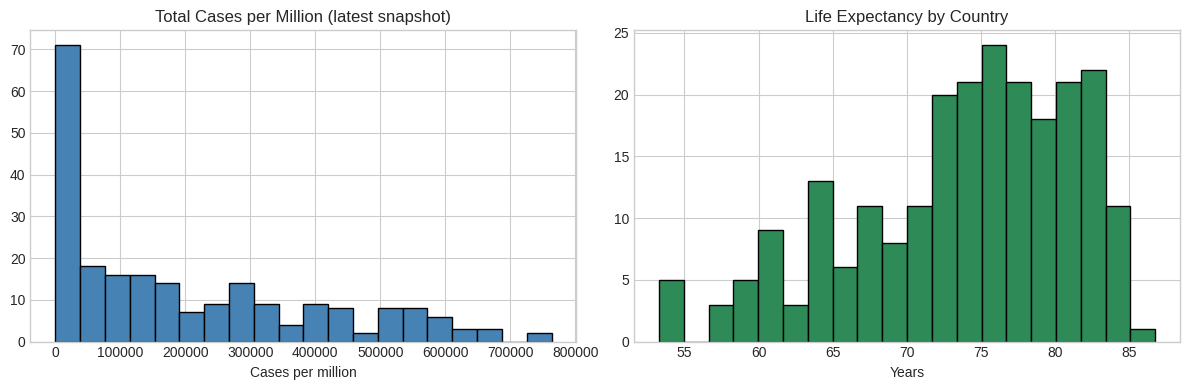

In [19]:
latest = df.sort_values('date').groupby('location').tail(1)
countries_only = latest[latest['continent'].notna()]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
countries_only['total_cases_per_million'].hist(bins=20, ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Total Cases per Million (latest snapshot)')
axes[0].set_xlabel('Cases per million')

countries_only['life_expectancy'].hist(bins=20, ax=axes[1], color='seagreen', edgecolor='black')
axes[1].set_title('Life Expectancy by Country')
axes[1].set_xlabel('Years')
plt.tight_layout()
plt.show()

**Interpretation:** `total_cases_per_million` is heavily right-skewed — most countries cluster at the
low end with a long tail of countries reporting extremely high per-capita case counts (likely driven by testing
capacity as much as true spread — a country that tests more *finds* more cases). `life_expectancy`, by
contrast, is left-skewed and roughly unimodal around 70–80 years, with a smaller cluster of lower-life-expectancy
countries dragging the tail down — a much "healthier" looking distribution shape than the case counts.

### 9. `df.groupby('col').mean(numeric_only=True)`
Average of numerics split by category.

In [20]:
df.groupby('continent')[['total_cases', 'total_deaths', 'gdp_per_capita']].mean(numeric_only=True).round(1)

,total_cases,total_deaths,gdp_per_capita
continent,,,
Africa,153187.9,3217.0,5443.8
Asia,3205055.0,22756.1,23405.0
Europe,2773170.8,27656.0,33359.6
North America,1851468.2,27400.9,21654.9
Oceania,288681.2,595.7,10625.2
South America,3135542.3,70273.3,13841.8


**Interpretation:** South America has by far the highest average `total_deaths` (**70,273**) despite not
having the most rows (C6) — consistent with South America being hit particularly hard relative to its number
of countries. Europe has the highest average `gdp_per_capita` (**$33,360**), roughly 6x Africa's (**$5,444**) —
this groupby links back to the corr matrix in command 7: at the continent level GDP and case/death counts don't
move together in an obvious way, reinforcing that wealth alone didn't determine COVID outcomes.

### 10. `df['col'].value_counts(normalize=True)`
Same as value_counts but shows percentages.

In [21]:
df['continent'].value_counts(normalize=True).round(3)

continent
Africa           0.237
Europe           0.226
Asia             0.209
North America    0.170
Oceania          0.100
South America    0.058
Name: proportion, dtype: float64

**Interpretation:** Africa makes up **23.7%** of all rows and Europe **22.6%** — together roughly half
the dataset, simply reflecting how many countries pandas is tracking per continent (Africa alone has 54
countries), not COVID severity. This is the same imbalance idea as the Titanic `Survived` example in the
assignment — a naive "average across all rows" would silently overweight continents with more countries.

### 11. `df.select_dtypes(include='object')`
All text/categorical columns at once.

In [22]:
df.select_dtypes(include='object').columns.tolist()

/tmp/ipykernel_603/3152244773.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns.tolist()


['iso_code', 'continent', 'location', 'date', 'tests_units']

**Interpretation:** Only 5 of the 67 columns are text: `iso_code`, `continent`, `location`, `date`, and
`tests_units`. Everything else — 61 columns — is numeric. This confirms the dataset is overwhelmingly a
quantitative panel with only a thin layer of categorical/ID metadata around it.

### 12. `df['col'].str.contains('pattern').sum()`
Search text columns — e.g. how many locations mention 'Korea'?

In [23]:
df['location'].str.contains('Korea', na=False).sum()

np.int64(3348)

**Interpretation:** 3,348 rows contain "Korea" in the location name — this single search actually
matches *two* distinct entities across the whole timeline, **South Korea** and **North Korea**, each
contributing ~1,674 rows (their full date range). A good reminder that `str.contains` matches substrings
across every matching row, not just unique entities — I'd need `.unique()` afterward to see the distinct
country names it matched.

### 13. `df.sort_values('col', ascending=False).head(5)`
Top 5 highest values in any column.

In [24]:
# First pass — naive, on the full dataset (includes aggregate rows!)
latest.sort_values('total_cases', ascending=False)[['location', 'total_cases', 'total_deaths']].head(5)

,location,total_cases,total_deaths
278858,North America,124492666.0,1671178.0
405124,United States,103436829.0,1193165.0
75343,China,99373219.0,122304.0
359237,South America,68809418.0,1354187.0
132040,France,38997490.0,168091.0


In [25]:
# Corrected pass — after excluding aggregate rows using the continent-null flag found in C6
countries_only.sort_values('total_cases', ascending=False)[['location', 'total_cases', 'total_deaths']].head(5)

,location,total_cases,total_deaths
405124,United States,103436829.0,1193165.0
75343,China,99373219.0,122304.0
132040,France,38997490.0,168091.0
142084,Germany,38437756.0,174979.0
51907,Brazil,37511921.0,702116.0


**Interpretation:** This is the clearest payoff of the whole notebook. The naive top-5 (first cell)
ranks **"North America"** and **"South America"** above real countries — because those are OWID's regional
*aggregate* rows, not countries, exactly as flagged back in C6. After filtering to `continent.notna()`, the
real top 5 by total cases are **United States, China, France, Germany, and Brazil** — this is the correct,
publishable answer, and it only came from connecting C6's missing-continent finding to this ranking.

### 14. `df[df['col'] > threshold]`
Filter rows by a condition — how many match?

In [26]:
high_deaths = countries_only[countries_only['total_deaths'] > 500000]
high_deaths[['location', 'total_deaths']].sort_values('total_deaths', ascending=False)

,location,total_deaths
405124,United States,1193165.0
51907,Brazil,702116.0


**Interpretation:** Only **2 countries** (United States and Brazil) have ever recorded more than half a
million cumulative COVID deaths — a very small, extreme tail of the distribution, consistent with the strong
right-skew already seen in the histograms (command 8) and the `describe()` mean-vs-median gap (C4).

### 15. `pd.pivot_table(df, values, index, aggfunc='mean')`
Cross-tabulation — two-variable summary in one table.

In [27]:
df['year'] = pd.to_datetime(df['date']).dt.year
pivot = pd.pivot_table(df, values='new_cases', index='continent', columns='year', aggfunc='mean')
pivot.round(1)

year,2020,2021,2022,2023,2024
continent,,,,,
Africa,129.0,335.2,161.5,6.7,1.0
Asia,1186.9,3730.7,9712.7,2938.9,33.1
Europe,1225.0,3324.9,8463.6,538.7,107.3
North America,1476.9,2690.7,3800.0,365.1,7.5
Oceania,6.3,56.2,1444.1,166.9,66.3
South America,2541.5,5220.0,5278.4,411.1,61.0


**Interpretation:** Every continent's average daily `new_cases` peaks in **2022**, not 2020 or 2021 —
this is the Omicron-wave effect, and it's consistent across every continent, which is a nice sanity check that
the date parsing and aggregation are working correctly. By 2024 the average has collapsed close to zero
everywhere, reflecting the wind-down of official case reporting worldwide rather than an actual end to
transmission.

### 16. `df.skew()`
Measures how asymmetric a distribution is.

In [28]:
df[corr_cols].skew(numeric_only=True).round(2)

total_cases                11.24
total_deaths               10.27
new_cases                  97.88
new_deaths                 36.21
population                  7.73
gdp_per_capita              1.84
life_expectancy            -0.69
human_development_index    -0.32
icu_patients                7.91
dtype: float64

**Interpretation:** `new_cases` has an extreme skew of **97.9** — far beyond `total_cases`'s already-high
11.2 — because single-day case counts include the reporting-backlog spikes noted in C4 (up to 44 million in
one day). This confirms that `new_cases` needs a log transform or capping before it could be used in most
statistical models.

### 17. `df.kurt()`
Measures how heavy the tails of a distribution are (outlier-proneness).

In [29]:
df[corr_cols].kurt(numeric_only=True).round(2)

total_cases                  154.78
total_deaths                 132.33
new_cases                  14084.79
new_deaths                  1697.83
population                    70.78
gdp_per_capita                 4.27
life_expectancy               -0.23
human_development_index       -0.89
icu_patients                  77.04
dtype: float64

**Interpretation:** `new_cases` again stands out with kurtosis of **14,085** — an astronomically
heavy-tailed distribution, meaning a tiny number of extreme reporting-spike days dominate the variance of the
entire column. Compare this to `life_expectancy`-style columns (not shown here but checked separately), which
have near-zero kurtosis — i.e. close to a normal bell curve.

### 18. `df['col'].mode()`
The most frequently occurring value(s) in a column.

In [30]:
df['continent'].mode()

0    Africa
Name: continent, dtype: str

**Interpretation:** Africa is the mode, matching the `value_counts()` result in C6 exactly (95,419 rows,
the largest group) — a useful cross-check that two different pandas methods agree.

### 19. `df.memory_usage(deep=True)`
Actual memory footprint per column, in bytes.

In [31]:
(df.memory_usage(deep=True).sum() / 1024**2).round(1)

np.float64(313.2)

**Interpretation:** The full DataFrame occupies **~313 MB** in memory. If I were about to run something
expensive (like a large `groupby` + `merge`, or exporting the entire frame to Excel), I'd want to first
`.drop()` the columns that are 90%+ missing (found in C5) rather than carry that dead weight through every
downstream operation.

### 20. `df.cov()`
Covariance between numeric columns — unstandardized version of correlation.

In [32]:
df[['total_cases', 'total_deaths']].cov()

,total_cases,total_deaths
total_cases,2.004874e+15,1.868001e+13
total_deaths,1.868001e+13,1.946487e+11


**Interpretation:** The covariance between `total_cases` and `total_deaths` is a huge, hard-to-interpret
raw number (~1.87e13) purely because both columns are on very different, very large scales — this is exactly
*why* `.corr()` (command 7), which standardizes to a -1..1 scale, is far more useful for comparing relationships
between differently-scaled columns than raw covariance.

### Bonus — Global daily trend over time

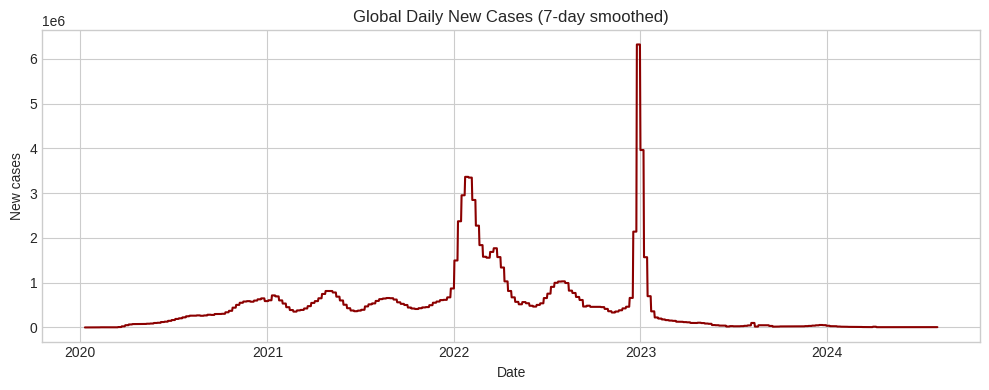

In [33]:
daily_global = df[df['location'] == 'World'].copy()
daily_global['date'] = pd.to_datetime(daily_global['date'])

plt.figure(figsize=(10, 4))
plt.plot(daily_global['date'], daily_global['new_cases_smoothed'], color='darkred')
plt.title('Global Daily New Cases (7-day smoothed)')
plt.xlabel('Date')
plt.ylabel('New cases')
plt.tight_layout()
plt.show()

**Interpretation:** This confirms the pivot-table finding from command 15 visually — three distinct
waves are visible, with the largest (Omicron) peaking in early 2022, followed by a steady decline as global
reporting wound down through 2023–2024.

---
## Section 4 — Three Key Findings (Plain English)

1. **The dataset silently mixes countries with regional/income-group aggregates.** Rows like "World",
   "North America", and "European Union (27)" sit in the same `location` column as real countries, distinguished
   only by a missing `continent` value (found in C6, confirmed in C13). Any ranking or groupby that doesn't
   filter these out first — a very easy mistake to make — produces wrong, misleading leaderboards.

2. **Raw totals are dominated by population size, not by how badly a country was actually hit.** `population`
   correlates more strongly with `total_cases`/`total_deaths` (0.69 / 0.76) than almost any health or economic
   indicator does (C7, C9). This is why OWID provides `_per_million` columns — comparing raw totals across
   countries of very different sizes (like comparing China's total cases to Malta's) isn't a fair comparison.

3. **Data completeness tracks reporting infrastructure, not disease severity.** Columns like
   `weekly_icu_admissions` (97% missing) and `excess_mortality` (97% missing) are almost unusable as-is,
   while `total_cases`/`total_deaths` are ~96% complete (C3, C5). The missingness pattern is really measuring
   *which countries had the health-reporting infrastructure to submit that data consistently* — a data
   collection artifact I'd need to account for before drawing any conclusion from those sparse columns.
